<a href="https://colab.research.google.com/github/Raksh1707/taskdeeplearning/blob/main/dltask2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)


In [3]:
input_size = 128
hidden_size = 128
num_layers = 20
batch_size = 64
epochs = 10


In [4]:
# Xavier Initialization
def xavier_init(fan_in, fan_out):
    limit = np.sqrt(6 / (fan_in + fan_out))
    w = torch.empty(fan_in, fan_out)
    w.uniform_(-limit, limit)
    w.requires_grad = False
    return w

In [5]:
# Kaiming Initialization
# -----------------------------
def kaiming_init(fan_in, fan_out):
    std = np.sqrt(2 / fan_in)
    w = torch.randn(fan_in, fan_out) * std
    w.requires_grad = False
    return w

In [6]:
# Build 20-layer MLP
# -----------------------------
def build_network(init_type="xavier"):
    weights = []

    for i in range(num_layers):
        if init_type == "xavier":
            w = xavier_init(hidden_size, hidden_size)
        else:
            w = kaiming_init(hidden_size, hidden_size)
        weights.append(w)

    return weights


In [7]:
def forward(weights, x):
    activations = []

    for w in weights:
        x = torch.matmul(x, w)
        x = torch.relu(x)
        activations.append(x.clone())

    return activations

In [8]:
def backward(weights):

    grad = torch.ones(batch_size, hidden_size)

    gradients = []

    for w in reversed(weights):
        grad = torch.matmul(grad, w.t())
        gradients.append(grad.clone())

    gradients.reverse()

    return gradients


In [9]:
# Tracking Function
# -----------------------------
def run(init_type):

    weights = build_network(init_type)

    act_mean = []
    act_var = []

    grad_mean = []
    grad_var = []

    for epoch in range(epochs):

        x = torch.randn(batch_size, hidden_size)

        activations = forward(weights, x)
        gradients = backward(weights)

        mean_a = [a.mean().item() for a in activations]
        var_a = [a.var().item() for a in activations]

        mean_g = [g.mean().item() for g in gradients]
        var_g = [g.var().item() for g in gradients]

        act_mean.append(np.mean(mean_a))
        act_var.append(np.mean(var_a))

        grad_mean.append(np.mean(mean_g))
        grad_var.append(np.mean(var_g))

    return act_mean, act_var, grad_mean, grad_var

In [10]:
x_mean, x_var, x_gmean, x_gvar = run("xavier")
k_mean, k_var, k_gmean, k_gvar = run("kaiming")

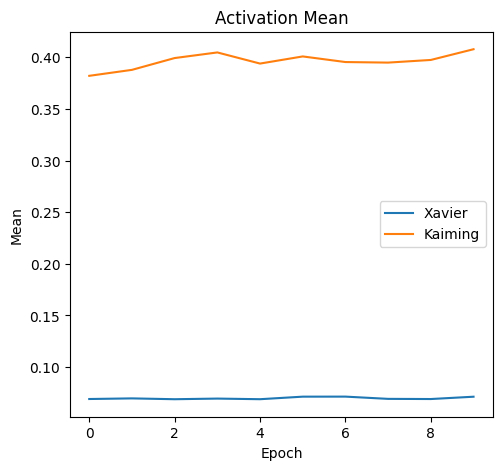

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x_mean, label="Xavier")
plt.plot(k_mean, label="Kaiming")
plt.title("Activation Mean")
plt.xlabel("Epoch")
plt.ylabel("Mean")
plt.legend()

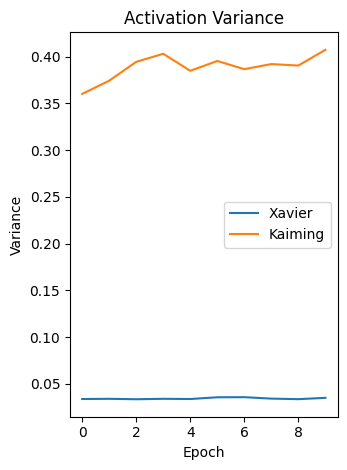

In [12]:
plt.subplot(1,2,2)
plt.plot(x_var, label="Xavier")
plt.plot(k_var, label="Kaiming")
plt.title("Activation Variance")
plt.xlabel("Epoch")
plt.ylabel("Variance")
plt.legend()

plt.tight_layout()
plt.show()


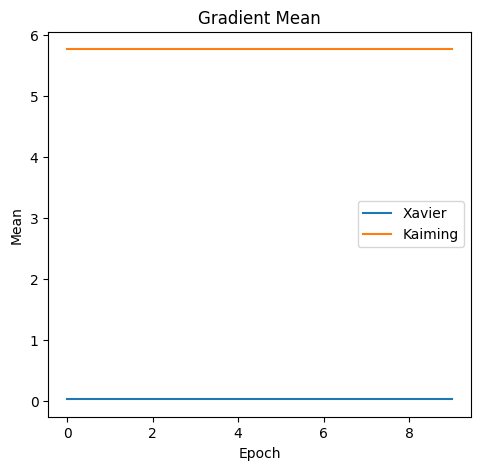

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x_gmean, label="Xavier")
plt.plot(k_gmean, label="Kaiming")
plt.title("Gradient Mean")
plt.xlabel("Epoch")
plt.ylabel("Mean")
plt.legend()

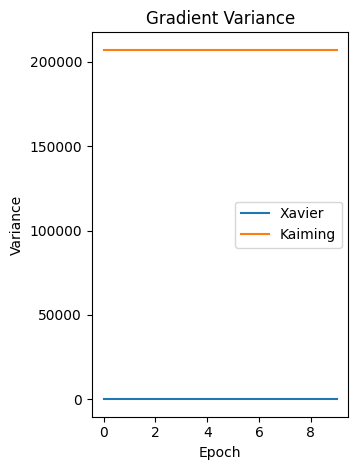

In [14]:
plt.subplot(1,2,2)
plt.plot(x_gvar, label="Xavier")
plt.plot(k_gvar, label="Kaiming")
plt.title("Gradient Variance")
plt.xlabel("Epoch")
plt.ylabel("Variance")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
print("----------- Xavier -----------")
print("Final Activation Mean :", x_mean[-1])
print("Final Activation Variance :", x_var[-1])
print("Final Gradient Mean :", x_gmean[-1])
print("Final Gradient Variance :", x_gvar[-1])

print("\n----------- Kaiming -----------")
print("Final Activation Mean :", k_mean[-1])
print("Final Activation Variance :", k_var[-1])
print("Final Gradient Mean :", k_gmean[-1])
print("Final Gradient Variance :", k_gvar[-1])

----------- Xavier -----------
Final Activation Mean : 0.07133245333388913
Final Activation Variance : 0.03488597582044264
Final Gradient Mean : 0.024391928501427174
Final Gradient Variance : 0.8329377353191376

----------- Kaiming -----------
Final Activation Mean : 0.4078460097312927
Final Activation Variance : 0.4074674718081951
Final Gradient Mean : 5.770648806262761
Final Gradient Variance : 207200.3727187395
